In [ ]:
import os
import sys
import json
import time
import math
import shutil
import inspect
import asyncio
import subprocess
from pathlib import Path
from collections import Counter

def pip_install(*packages):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "-U", *packages])

TOOLUNIVERSE_VERSION = os.environ.get("TOOLUNIVERSE_VERSION", "1.3.0")
pip_install(
    f"tooluniverse=={TOOLUNIVERSE_VERSION}",
    "pandas",
    "matplotlib",
    "networkx",
    "tqdm",
    "nest_asyncio",
)

import nest_asyncio
nest_asyncio.apply()

import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from tqdm.auto import tqdm
from IPython.display import display, Markdown

try:
    import tooluniverse
    from tooluniverse import ToolUniverse
except Exception as e:
    raise RuntimeError("ToolUniverse import failed. Restart Colab runtime once and run again.") from e

try:
    from google.colab import userdata
    if not os.environ.get("OPENROUTER_API_KEY"):
        key = userdata.get("OPENROUTER_API_KEY")
        if key:
            os.environ["OPENROUTER_API_KEY"] = key
except Exception:
    pass

In [ ]:
OUT_DIR = Path("/content/tooluniverse_advanced_tutorial_outputs")
CACHE_DIR = Path("/content/tooluniverse_cache")
OUT_DIR.mkdir(parents=True, exist_ok=True)
CACHE_DIR.mkdir(parents=True, exist_ok=True)

os.environ["TOOLUNIVERSE_CACHE_ENABLED"] = "true"
os.environ["TOOLUNIVERSE_CACHE_PERSIST"] = "true"
os.environ["TOOLUNIVERSE_CACHE_DIR"] = str(CACHE_DIR)
os.environ["TOOLUNIVERSE_CACHE_MEMORY_SIZE"] = "2048"
os.environ.setdefault("OPENROUTER_SITE_NAME", "ToolUniverse Colab Tutorial")
os.environ.setdefault("OPENROUTER_SITE_URL", "https://colab.research.google.com")

RESEARCH_CASE = {
    "disease_name": "rheumatoid arthritis",
    "disease_efo_id": "EFO_0000685",
    "candidate_drug": "methotrexate",
    "literature_query": "rheumatoid arthritis TNF IL6 JAK methotrexate therapy",
    "protein_accessions": {
        "TNF": "P01375",
        "IL6": "P05231",
        "JAK1": "P23458",
        "STAT3": "P40763",
        "PTPN22": "Q9Y2R2",
    },
}

INCLUDE_TOOLS = [
    "Tool_Finder_Keyword",
    "UniProt_get_function_by_accession",
    "UniProt_get_entry_by_accession",
    "OpenTargets_get_associated_targets_by_disease_efoId",
    "PubMed_search_articles",
    "EuropePMC_search_articles",
    "openalex_literature_search",
    "SemanticScholar_search_papers",
    "ArXiv_search_papers",
    "Crossref_search_works",
    "PubChem_get_CID_by_compound_name",
    "PubChem_get_compound_properties_by_CID",
    "PubChem_get_compound_synonyms_by_CID",
    "PubChem_get_compound_bioactivity",
    "FAERS_count_reactions_by_drug_event",
    "OpenFDA_search_drug_events",
    "OpenFDA_search_drug_labels",
    "OpenFDA_search_drug_enforcement",
    "ClinicalTrials_search_studies",
]

In [ ]:
def safe_json(obj, max_chars=None):
    try:
        txt = json.dumps(obj, indent=2, ensure_ascii=False, default=str)
    except Exception:
        txt = str(obj)
    if max_chars and len(txt) > max_chars:
        return txt[:max_chars] + "\n...TRUNCATED..."
    return txt

def preview(obj, max_chars=1600):
    print(safe_json(obj, max_chars=max_chars))

async def maybe_await(obj):
    if inspect.isawaitable(obj):
        return await obj
    return obj

def get_loaded_tool_names(tu):
    for attr in ["all_tools", "tools", "tool_registry"]:
        obj = getattr(tu, attr, None)
        if isinstance(obj, dict):
            return set(obj.keys())
        if isinstance(obj, list):
            names = set()
            for item in obj:
                if isinstance(item, dict) and item.get("name"):
                    names.add(item["name"])
                elif hasattr(item, "name"):
                    names.add(item.name)
                else:
                    names.add(str(item))
            return names
    return set()

def tool_exists(tu, name):
    names = get_loaded_tool_names(tu)
    return True if not names else name in names

async def load_tutorial_tools():
    tu = ToolUniverse()
    try:
        maybe = tu.load_tools(include_tools=INCLUDE_TOOLS)
        await maybe_await(maybe)
        mode = "selected"
    except TypeError:
        maybe = tu.load_tools()
        await maybe_await(maybe)
        mode = "full_fallback_typeerror"
    except Exception as e:
        print("Selective loading failed. Loading all tools instead.")
        print("Reason:", str(e)[:300])
        maybe = tu.load_tools()
        await maybe_await(maybe)
        mode = "full_fallback_exception"

    loaded = get_loaded_tool_names(tu)
    missing = [x for x in INCLUDE_TOOLS if loaded and x not in loaded]

    if missing:
        print("Missing after selective load:", missing)
        print("Loading full ToolUniverse registry once.")
        maybe = tu.load_tools()
        await maybe_await(maybe)
        mode = "full_after_missing"
        loaded = get_loaded_tool_names(tu)

    print("Loaded mode:", mode)
    print("Visible loaded tools:", len(loaded) if loaded else "unknown")
    return tu

async def run_tool(tu, name, arguments=None, use_cache=True, retries=2, sleep_base=1.0, verbose=True):
    arguments = arguments or {}

    if not tool_exists(tu, name):
        return {
            "error": f"Tool '{name}' is not visible in the loaded ToolUniverse registry.",
            "name": name,
            "arguments": arguments,
        }

    last_error = None

    for attempt in range(retries + 1):
        start = time.time()
        try:
            try:
                result = tu.run({"name": name, "arguments": arguments}, use_cache=use_cache)
            except TypeError:
                result = tu.run({"name": name, "arguments": arguments})

            result = await maybe_await(result)

            elapsed = time.time() - start
            if verbose:
                print(f"✓ {name} completed in {elapsed:.2f}s")
            return result

        except Exception as e:
            last_error = e
            if attempt < retries:
                delay = sleep_base * (2 ** attempt)
                print(f"Retrying {name}; reason: {str(e)[:200]}")
                await asyncio.sleep(delay)

    return {
        "error": str(last_error),
        "name": name,
        "arguments": arguments,
    }

def deep_find_first(obj, wanted_key, max_depth=10):
    if max_depth < 0:
        return None
    if isinstance(obj, dict):
        if wanted_key in obj:
            return obj[wanted_key]
        for v in obj.values():
            found = deep_find_first(v, wanted_key, max_depth - 1)
            if found is not None:
                return found
    elif isinstance(obj, list):
        for v in obj:
            found = deep_find_first(v, wanted_key, max_depth - 1)
            if found is not None:
                return found
    return None

def collect_record_lists(obj, max_depth=8):
    lists = []

    def rec(x, depth):
        if depth < 0:
            return
        if isinstance(x, list):
            if x and all(isinstance(v, dict) for v in x[: min(len(x), 5)]):
                lists.append(x)
            for v in x[:5]:
                rec(v, depth - 1)
        elif isinstance(x, dict):
            for v in x.values():
                rec(v, depth - 1)

    rec(obj, max_depth)
    return lists

def records_from_any_result(obj):
    if isinstance(obj, list) and all(isinstance(x, dict) for x in obj):
        return obj
    candidates = collect_record_lists(obj)
    if not candidates:
        return []
    return max(candidates, key=len)

def first_nonempty(*values):
    for value in values:
        if value not in [None, "", [], {}]:
            return value
    return None

def extract_first_int_by_key(obj, possible_keys=("CID", "cid")):
    if isinstance(obj, dict):
        for k, v in obj.items():
            if k in possible_keys:
                if isinstance(v, list) and v:
                    try:
                        return int(v[0])
                    except Exception:
                        pass
                try:
                    return int(v)
                except Exception:
                    pass
        for v in obj.values():
            found = extract_first_int_by_key(v, possible_keys)
            if found is not None:
                return found
    elif isinstance(obj, list):
        for v in obj:
            found = extract_first_int_by_key(v, possible_keys)
            if found is not None:
                return found
    return None

def normalize_author_list(authors):
    if not authors:
        return ""
    if isinstance(authors, str):
        return authors[:400]
    if isinstance(authors, list):
        names = []
        for a in authors[:8]:
            if isinstance(a, str):
                names.append(a)
            elif isinstance(a, dict):
                name = first_nonempty(
                    a.get("name"),
                    a.get("full_name"),
                    a.get("display_name"),
                    " ".join([str(a.get("given", "")), str(a.get("family", ""))]).strip(),
                )
                if name:
                    names.append(name)
        return "; ".join(names)[:500]
    return str(authors)[:400]

def normalize_paper(source, rec):
    if not isinstance(rec, dict):
        return None

    title = first_nonempty(
        rec.get("title"),
        rec.get("display_name"),
        rec.get("paperTitle"),
        rec.get("articleTitle"),
        rec.get("name"),
    )

    if isinstance(title, list):
        title = " ".join(map(str, title))

    abstract = first_nonempty(
        rec.get("abstract"),
        rec.get("summary"),
        rec.get("description"),
        rec.get("abstractText"),
        rec.get("snippet"),
    )

    doi = first_nonempty(rec.get("doi"), rec.get("DOI"))
    if isinstance(doi, list):
        doi = doi[0] if doi else None

    year = first_nonempty(
        rec.get("year"),
        rec.get("publication_year"),
        rec.get("pub_year"),
        rec.get("published_year"),
    )

    if not year:
        date = first_nonempty(
            rec.get("publication_date"),
            rec.get("published"),
            rec.get("published_date"),
            rec.get("date"),
        )
        if date:
            year = str(date)[:4]

    url = first_nonempty(
        rec.get("url"),
        rec.get("paper_url"),
        rec.get("link"),
        rec.get("doi_url"),
        rec.get("landing_page_url"),
    )

    citations = first_nonempty(
        rec.get("citations"),
        rec.get("citation_count"),
        rec.get("cited_by_count"),
        rec.get("influentialCitationCount"),
    )

    if not title:
        return None

    return {
        "source": source,
        "title": str(title).strip(),
        "abstract": str(abstract).strip() if abstract else "",
        "doi": str(doi).lower().replace("https://doi.org/", "").strip() if doi else "",
        "year": year,
        "authors": normalize_author_list(rec.get("authors") or rec.get("authorships")),
        "citations": citations,
        "url": url,
        "raw": rec,
    }

def dedupe_papers(papers):
    seen = set()
    out = []
    for p in papers:
        key = p["doi"] or p["title"].lower().strip()
        key = " ".join(key.split())
        if key in seen:
            continue
        seen.add(key)
        out.append(p)
    return out

def parse_opentargets_targets(result, max_targets=30):
    rows = None

    try:
        rows = result["data"]["disease"]["associatedTargets"]["rows"]
    except Exception:
        rows = deep_find_first(result, "rows")

    if not isinstance(rows, list):
        rows = records_from_any_result(result)

    parsed = []

    for row in rows:
        if not isinstance(row, dict):
            continue

        target = row.get("target", {}) if isinstance(row.get("target", {}), dict) else {}

        symbol = first_nonempty(
            target.get("approvedSymbol"),
            target.get("symbol"),
            target.get("geneSymbol"),
            row.get("approvedSymbol"),
            row.get("symbol"),
            row.get("gene"),
            row.get("id"),
        )

        target_id = first_nonempty(
            target.get("id"),
            row.get("targetId"),
            row.get("id"),
        )

        name = first_nonempty(
            target.get("approvedName"),
            target.get("name"),
            row.get("name"),
        )

        score = first_nonempty(
            row.get("score"),
            row.get("associationScore"),
            row.get("overallScore"),
            deep_find_first(row, "score", max_depth=2),
        )

        try:
            score = float(score)
        except Exception:
            score = None

        if symbol:
            parsed.append(
                {
                    "symbol": str(symbol),
                    "target_id": target_id,
                    "target_name": name,
                    "association_score": score,
                    "raw": row,
                }
            )

    parsed = sorted(
        parsed,
        key=lambda x: -1 if x["association_score"] is None else x["association_score"],
        reverse=True,
    )

    return parsed[:max_targets]

def compact_result_for_csv(obj, limit=1000):
    return safe_json(obj, max_chars=limit).replace("\n", " ")

In [ ]:
async def collect_base_evidence():
    display(Markdown("# ToolUniverse Advanced Colab Tutorial"))
    print("ToolUniverse version:", getattr(tooluniverse, "__version__", "unknown"))
    print("Output directory:", OUT_DIR)
    print("Cache directory:", CACHE_DIR)

    tu = await load_tutorial_tools()

    display(Markdown("## 1. Tool discovery"))

    finder_result = await run_tool(
        tu,
        "Tool_Finder_Keyword",
        {
            "description": "rheumatoid arthritis disease target drug safety literature protein database",
            "limit": 12,
        },
        use_cache=True,
    )
    preview(finder_result, 2000)

    display(Markdown("## 2. Tool specifications"))

    spec_rows = []
    for name in INCLUDE_TOOLS:
        spec = {}
        try:
            try:
                spec = tu.tool_specification(name, format="openai")
            except TypeError:
                spec = tu.tool_specification(name)
            spec = await maybe_await(spec)
        except Exception as e:
            spec = {"error": str(e)}

        spec_rows.append(
            {
                "tool": name,
                "available": tool_exists(tu, name),
                "description": str(spec.get("description", ""))[:260] if isinstance(spec, dict) else "",
                "has_parameters": isinstance(spec, dict) and bool(spec.get("parameters") or spec.get("parameter")),
                "error": spec.get("error", "") if isinstance(spec, dict) else "",
            }
        )

    spec_df = pd.DataFrame(spec_rows)
    display(spec_df)
    spec_df.to_csv(OUT_DIR / "tool_specs_summary.csv", index=False)

    display(Markdown("## 3. Parallel UniProt function retrieval"))

    async def protein_job(gene, accession):
        result = await run_tool(
            tu,
            "UniProt_get_function_by_accession",
            {"accession": accession},
            use_cache=True,
            verbose=False,
        )
        return {
            "gene": gene,
            "accession": accession,
            "function_preview": compact_result_for_csv(result, 900),
            "raw_result": result,
        }

    protein_rows = await asyncio.gather(
        *[
            protein_job(gene, accession)
            for gene, accession in RESEARCH_CASE["protein_accessions"].items()
        ]
    )

    protein_df = pd.DataFrame(
        [{k: v for k, v in row.items() if k != "raw_result"} for row in protein_rows]
    )
    display(protein_df)

    with open(OUT_DIR / "protein_function_results.json", "w", encoding="utf-8") as f:
        json.dump(protein_rows, f, indent=2, ensure_ascii=False, default=str)

    display(Markdown("## 4. Disease-target association mining with OpenTargets"))

    target_result = await run_tool(
        tu,
        "OpenTargets_get_associated_targets_by_disease_efoId",
        {"efoId": RESEARCH_CASE["disease_efo_id"]},
        use_cache=True,
    )

    target_rows = parse_opentargets_targets(target_result, max_targets=30)
    target_df = pd.DataFrame([{k: v for k, v in r.items() if k != "raw"} for r in target_rows])

    if target_df.empty:
        print("No OpenTargets rows were parsed. Raw preview:")
        preview(target_result, 2500)
    else:
        display(target_df.head(15))

    target_df.to_csv(OUT_DIR / "opentargets_top_targets.csv", index=False)

    with open(OUT_DIR / "opentargets_raw_result.json", "w", encoding="utf-8") as f:
        json.dump(target_result, f, indent=2, ensure_ascii=False, default=str)

    display(Markdown("## 5. Multi-source literature search"))

    literature_plan = [
        {
            "source": "PubMed",
            "tool": "PubMed_search_articles",
            "arguments": {"query": RESEARCH_CASE["literature_query"], "limit": 5},
        },
        {
            "source": "EuropePMC",
            "tool": "EuropePMC_search_articles",
            "arguments": {"query": RESEARCH_CASE["literature_query"], "limit": 5},
        },
        {
            "source": "OpenAlex",
            "tool": "openalex_literature_search",
            "arguments": {
                "search_keywords": RESEARCH_CASE["literature_query"],
                "max_results": 5,
                "year_from": 2018,
                "open_access": True,
            },
        },
        {
            "source": "SemanticScholar",
            "tool": "SemanticScholar_search_papers",
            "arguments": {"query": RESEARCH_CASE["literature_query"], "limit": 5},
        },
        {
            "source": "Crossref",
            "tool": "Crossref_search_works",
            "arguments": {
                "query": RESEARCH_CASE["literature_query"],
                "limit": 5,
                "filter": "type:journal-article,from-pub-date:2018-01-01",
            },
        },
    ]

    async def literature_job(plan):
        result = await run_tool(
            tu,
            plan["tool"],
            plan["arguments"],
            use_cache=True,
            retries=1,
            verbose=True,
        )
        return plan["source"], result

    literature_pairs = await asyncio.gather(*[literature_job(p) for p in literature_plan])
    raw_literature = dict(literature_pairs)

    papers = []
    for source, raw in raw_literature.items():
        records = records_from_any_result(raw)
        for rec in records:
            normalized = normalize_paper(source, rec)
            if normalized:
                papers.append(normalized)

    papers = dedupe_papers(papers)
    paper_df = pd.DataFrame([{k: v for k, v in p.items() if k != "raw"} for p in papers])

    if paper_df.empty:
        print("No literature rows were parsed. Raw previews:")
        for source, raw in raw_literature.items():
            print("\nSOURCE:", source)
            preview(raw, 1400)
    else:
        display(paper_df.head(20))

    paper_df.to_csv(OUT_DIR / "literature_results_deduplicated.csv", index=False)

    with open(OUT_DIR / "literature_raw_results.json", "w", encoding="utf-8") as f:
        json.dump(raw_literature, f, indent=2, ensure_ascii=False, default=str)

    return {
        "tu": tu,
        "finder_result": finder_result,
        "spec_df": spec_df,
        "protein_rows": protein_rows,
        "target_result": target_result,
        "target_df": target_df,
        "raw_literature": raw_literature,
        "paper_df": paper_df,
        "papers": papers,
    }

# ToolUniverse Advanced Colab Tutorial

ToolUniverse version: 1.3.0
Output directory: /content/tooluniverse_advanced_tutorial_outputs
Cache directory: /content/tooluniverse_cache
ℹ️  Including only specific tools: 19 tools specified


INFO:tooluniverse.ToolUniverse:Including only specific tools: 19 tools specified


ℹ️  Included 19 tools by name filter


INFO:tooluniverse.ToolUniverse:Included 19 tools by name filter


...

## 6. Drug identity, properties, adverse-event, label, recall, and trial lookups

✓ PubChem_get_CID_by_compound_name completed in 0.81s
✓ PubChem_get_compound_properties_by_CID completed in 0.35s
✓ PubChem_get_compound_synonyms_by_CID completed in 0.18s
✓ PubChem_get_compound_bioactivity completed in 10.51s
✓ FAERS_count_reactions_by_drug_event completed in 0.50s
✓ OpenFDA_search_drug_events completed in 0.46s
✓ OpenFDA_search_drug_labels completed in 0.37s
✓ OpenFDA_search_drug_enforcement completed in 0.32s
✓ ClinicalTrials_search_studies completed in 0.13s
Parsed PubChem CID: 126941

PubChem properties preview
{
  "status": "success",
  "data": {
    "PropertyTable": {
      "Properties": [
        {
          "CID": 126941,
          "MolecularFormula": "C20H22N8O5",
          "MolecularWeight": "454.4",
          "SMILES": "CN(CC1=CN=C2C(=N1)C(=NC(=N2)N)N)C3=CC=C(C=C3)C(=O)N[C@@H](CCC(=O)O)C(=O)O",
          "ConnectivitySMILES": "CN(CC1=CN=C2C(=N1)C(=NC(=N2)N)N)C3=CC=C(C=C3)C(=O)NC(CCC(=O)O)C(=O)O",
          "InChIKey": "FBOZXECLQNJBKD-ZDUSSCGKSA-N",
        

## 7. Evidence scoring layer

,symbol,target_name,association_score,literature_hits_in_returned_papers,combined_demo_signal
3,TNF,None,0.716626,8,0.787469
7,JAK1,None,0.690381,1,0.567786
0,TYK2,None,0.751787,0,0.563840
1,IL12B,None,0.732752,0,0.549564
2,IL6R,None,0.732460,0,0.549345
4,TRAF3IP2,None,0.713860,0,0.535395
5,MIF,None,0.697673,0,0.523255
6,JAK2,None,0.693433,0,0.520075
8,PADI4,None,0.689286,0,0.516965
9,PTPN22,None,0.679861,0,0.509896


## 8. Visualization

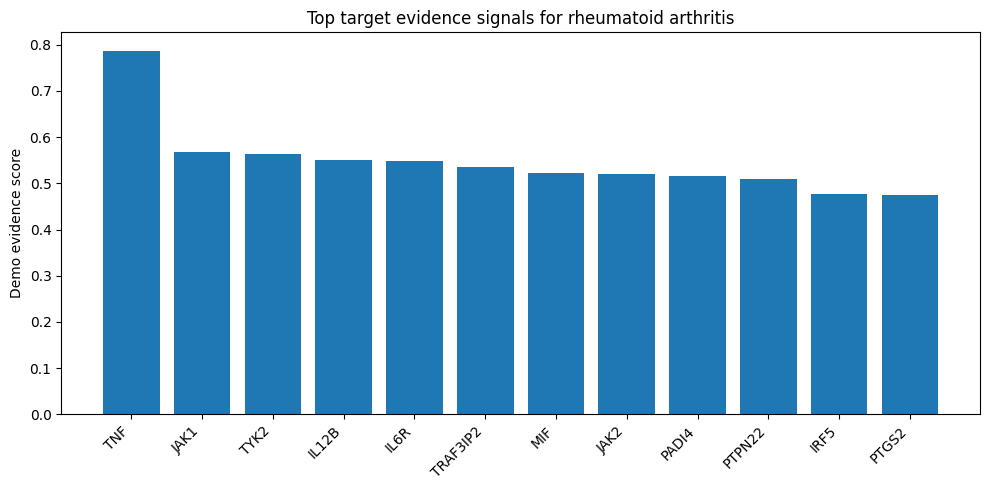

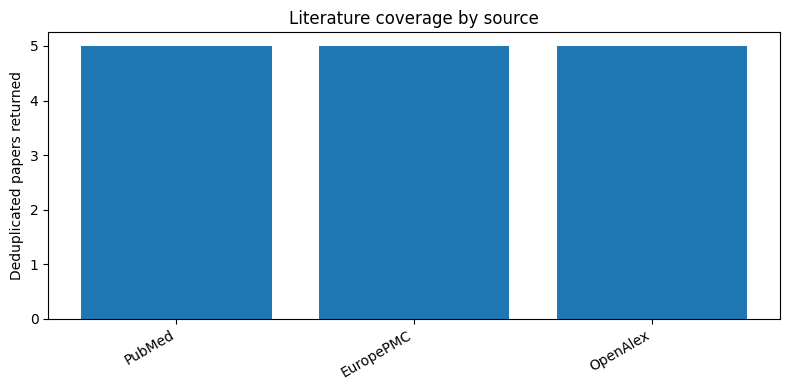

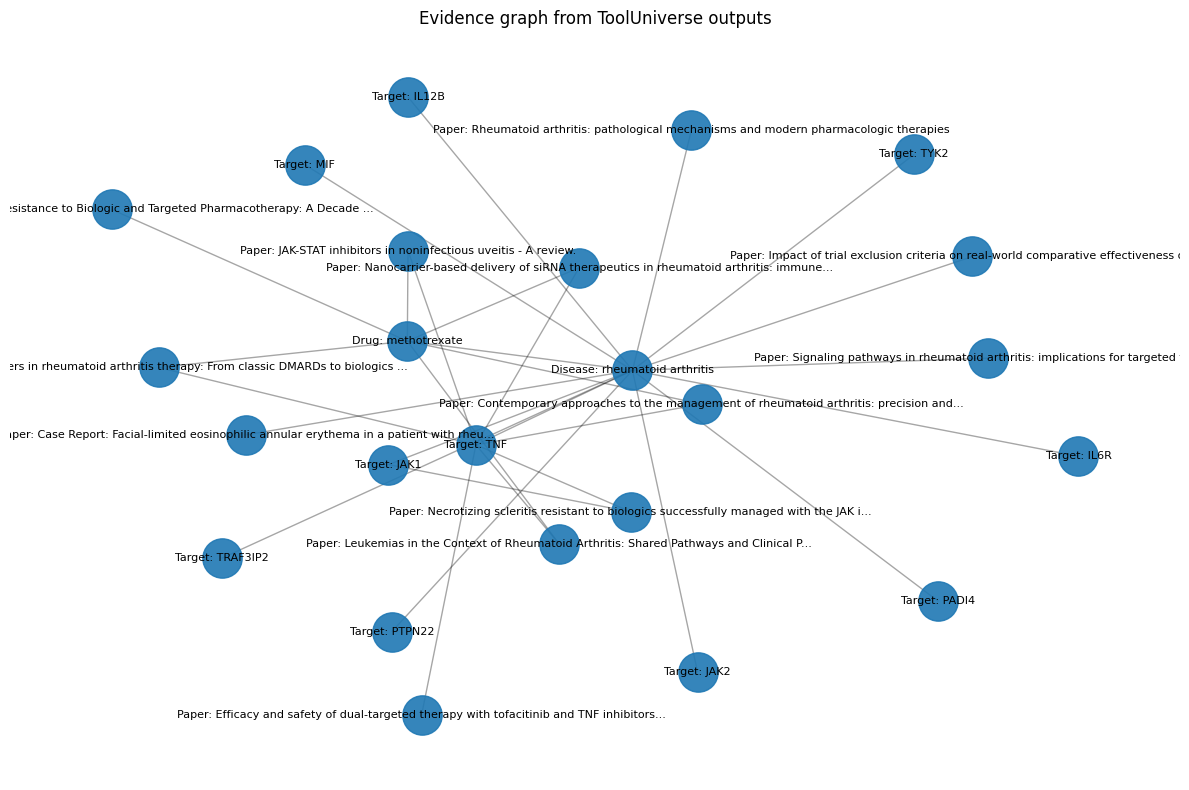

## 9. Optional OpenRouter synthesis

Research case: rheumatoid arthritis and methotrexate.
Parsed PubChem CID: 126941.
Deduplicated literature records collected: 15.
Top target signals from the demo scoring layer:
- TNF: association_score=0.7166256679552229, literature_hits=8, combined_demo_signal=0.787
- JAK1: association_score=0.6903808968126417, literature_hits=1, combined_demo_signal=0.568
- TYK2: association_score=0.7517870740478155, literature_hits=0, combined_demo_signal=0.564
- IL12B: association_score=0.7327522713447271, literature_hits=0, combined_demo_signal=0.550
- IL6R: association_score=0.732460258806829, literature_hits=0, combined_demo_signal=0.549
This workflow is for research and tool orchestration demonstration only, not medical advice.


## 10. Cache stats and export

Cache stats:
{
  "enabled": true,
  "memory": {
    "max_size": 2048,
    "current_size": 21,
    "hits": 0,
    "misses": 21
  },
  "persistent": {
    "enabled": true,
    "entries": 21,
    "approx_bytes": 1576555,
    "path": "/content/tooluniverse_cache/cache.sqlite"
  },
  "async_persist": true,
  "pending_writes": 0
}


## Tutorial complete

Saved files:
 - drug_and_safety_results.json
 - evidence_graph.graphml
 - evidence_graph.png
 - evidence_synthesis.txt
 - literature_raw_results.json
 - literature_results_deduplicated.csv
 - literature_source_counts.png
 - opentargets_raw_result.json
 - opentargets_top_targets.csv
 - protein_function_results.json
 - target_evidence_scores.png
 - target_evidence_signals.csv
 - tool_specs_summary.csv
 - tooluniverse_full_evidence_pack.json

ZIP archive: /content/tooluniverse_advanced_tutorial_outputs.zip

To download the ZIP, run:
files.download('/content/tooluniverse_advanced_tutorial_outputs.zip')


In [2]:
async def finalize_tutorial(state):
    tu = state["tu"]
    finder_result = state["finder_result"]
    spec_df = state["spec_df"]
    protein_rows = state["protein_rows"]
    target_df = state["target_df"]
    paper_df = state["paper_df"]
    papers = state["papers"]

    display(Markdown("## 6. Drug identity, properties, adverse-event, label, recall, and trial lookups"))

    drug = RESEARCH_CASE["candidate_drug"]

    cid_result = await run_tool(
        tu,
        "PubChem_get_CID_by_compound_name",
        {"compound_name": drug},
        use_cache=True,
        retries=1,
    )

    cid = extract_first_int_by_key(cid_result)

    if cid:
        pubchem_properties = await run_tool(
            tu,
            "PubChem_get_compound_properties_by_CID",
            {
                "cid": cid,
                "properties": [
                    "MolecularFormula",
                    "MolecularWeight",
                    "CanonicalSMILES",
                    "IsomericSMILES",
                    "IUPACName",
                    "InChIKey",
                    "XLogP",
                    "TPSA",
                ],
            },
            use_cache=True,
            retries=1,
        )

        pubchem_synonyms = await run_tool(
            tu,
            "PubChem_get_compound_synonyms_by_CID",
            {"cid": cid},
            use_cache=True,
            retries=1,
        )

        pubchem_bioactivity = await run_tool(
            tu,
            "PubChem_get_compound_bioactivity",
            {"cid": cid},
            use_cache=True,
            retries=1,
        )
    else:
        pubchem_properties = {"error": "Could not parse a PubChem CID.", "cid_result": cid_result}
        pubchem_synonyms = {"error": "Skipped because CID was unavailable."}
        pubchem_bioactivity = {"error": "Skipped because CID was unavailable."}

    faers_result = await run_tool(
        tu,
        "FAERS_count_reactions_by_drug_event",
        {"medicinalproduct": drug},
        use_cache=True,
        retries=1,
    )

    openfda_events = await run_tool(
        tu,
        "OpenFDA_search_drug_events",
        {
            "drug_name": drug,
            "count": "patient.reaction.reactionmeddrapt.exact",
            "limit": 20,
        },
        use_cache=True,
        retries=1,
    )

    openfda_labels = await run_tool(
        tu,
        "OpenFDA_search_drug_labels",
        {
            "search": f'openfda.generic_name:"{drug}" OR openfda.substance_name:"{drug}"',
            "limit": 3,
        },
        use_cache=True,
        retries=1,
    )

    openfda_recalls = await run_tool(
        tu,
        "OpenFDA_search_drug_enforcement",
        {
            "search": f'openfda.generic_name:"{drug}" OR product_description:"{drug}"',
            "limit": 5,
        },
        use_cache=True,
        retries=1,
    )

    clinical_trials_result = await run_tool(
        tu,
        "ClinicalTrials_search_studies",
        {
            "condition": RESEARCH_CASE["disease_name"],
            "intervention": drug,
        },
        use_cache=True,
        retries=1,
    )

    drug_pack = {
        "pubchem_cid": cid_result,
        "parsed_cid": cid,
        "pubchem_properties": pubchem_properties,
        "pubchem_synonyms": pubchem_synonyms,
        "pubchem_bioactivity": pubchem_bioactivity,
        "faers_tool": faers_result,
        "openfda_events": openfda_events,
        "openfda_labels": openfda_labels,
        "openfda_recalls": openfda_recalls,
        "clinical_trials": clinical_trials_result,
    }

    with open(OUT_DIR / "drug_and_safety_results.json", "w", encoding="utf-8") as f:
        json.dump(drug_pack, f, indent=2, ensure_ascii=False, default=str)

    print("Parsed PubChem CID:", cid)
    print("\nPubChem properties preview")
    preview(pubchem_properties, 1300)
    print("\nOpenFDA event preview")
    preview(openfda_events, 1300)
    print("\nOpenFDA label preview")
    preview(openfda_labels, 1300)

    display(Markdown("## 7. Evidence scoring layer"))

    top_symbols = []
    if not target_df.empty and "symbol" in target_df.columns:
        top_symbols = [x for x in target_df["symbol"].head(20).tolist() if isinstance(x, str)]

    paper_texts = []
    if not paper_df.empty:
        paper_texts = [
            f"{p.get('title', '')} {p.get('abstract', '')}".lower()
            for p in paper_df.to_dict(orient="records")
        ]

    symbol_lit_hits = Counter()
    for symbol in top_symbols:
        s = symbol.lower()
        if len(s) > 2:
            symbol_lit_hits[symbol] = sum(1 for txt in paper_texts if s in txt)

    signal_rows = []
    if not target_df.empty:
        for _, r in target_df.head(20).iterrows():
            symbol = r.get("symbol")
            score = r.get("association_score")
            score_norm = score if isinstance(score, (int, float)) and not math.isnan(score) else 0.0
            lit_hits = symbol_lit_hits.get(symbol, 0)
            lit_norm = min(lit_hits, 5) / 5
            combined = 0.75 * score_norm + 0.25 * lit_norm

            signal_rows.append(
                {
                    "symbol": symbol,
                    "target_name": r.get("target_name"),
                    "association_score": score,
                    "literature_hits_in_returned_papers": lit_hits,
                    "combined_demo_signal": combined,
                }
            )

    if signal_rows:
        signal_df = pd.DataFrame(signal_rows).sort_values("combined_demo_signal", ascending=False)
    else:
        signal_df = pd.DataFrame(
            columns=[
                "symbol",
                "target_name",
                "association_score",
                "literature_hits_in_returned_papers",
                "combined_demo_signal",
            ]
        )

    display(signal_df.head(15))
    signal_df.to_csv(OUT_DIR / "target_evidence_signals.csv", index=False)

    display(Markdown("## 8. Visualization"))

    if not signal_df.empty:
        plot_df = signal_df.head(12).copy()
        plt.figure(figsize=(10, 5))
        plt.bar(plot_df["symbol"], plot_df["combined_demo_signal"])
        plt.xticks(rotation=45, ha="right")
        plt.ylabel("Demo evidence score")
        plt.title(f"Top target evidence signals for {RESEARCH_CASE['disease_name']}")
        plt.tight_layout()
        plt.savefig(OUT_DIR / "target_evidence_scores.png", dpi=180)
        plt.show()
    else:
        print("Skipping target score plot because no target signals were parsed.")

    if not paper_df.empty and "source" in paper_df.columns:
        source_counts = paper_df["source"].value_counts()
        plt.figure(figsize=(8, 4))
        plt.bar(source_counts.index, source_counts.values)
        plt.xticks(rotation=30, ha="right")
        plt.ylabel("Deduplicated papers returned")
        plt.title("Literature coverage by source")
        plt.tight_layout()
        plt.savefig(OUT_DIR / "literature_source_counts.png", dpi=180)
        plt.show()
    else:
        print("Skipping literature plot because no literature rows were parsed.")

    G = nx.Graph()
    disease_node = f"Disease: {RESEARCH_CASE['disease_name']}"
    drug_node = f"Drug: {drug}"
    G.add_node(disease_node, node_type="disease")
    G.add_node(drug_node, node_type="drug")
    G.add_edge(disease_node, drug_node, relation="candidate_or_context_drug")

    if not signal_df.empty:
        for _, row in signal_df.head(10).iterrows():
            target_node = f"Target: {row['symbol']}"
            G.add_node(target_node, node_type="target")
            try:
                weight = float(row["association_score"])
            except Exception:
                weight = 0.0
            G.add_edge(disease_node, target_node, relation="OpenTargets_association", weight=weight)

    if not paper_df.empty:
        for _, p in paper_df.head(12).iterrows():
            title = str(p.get("title", "Untitled"))
            short_title = title[:80] + ("..." if len(title) > 80 else "")
            paper_node = f"Paper: {short_title}"
            G.add_node(
                paper_node,
                node_type="paper",
                source=p.get("source"),
                year=str(p.get("year", "")),
                doi=p.get("doi", ""),
            )

            text = f"{p.get('title', '')} {p.get('abstract', '')}".lower()
            attached = False

            for symbol in top_symbols[:12]:
                if symbol.lower() in text:
                    G.add_edge(paper_node, f"Target: {symbol}", relation="mentions_target")
                    attached = True

            if drug.lower() in text:
                G.add_edge(paper_node, drug_node, relation="mentions_drug")
                attached = True

            if not attached:
                G.add_edge(paper_node, disease_node, relation="topic_match")

    plt.figure(figsize=(12, 8))
    pos = nx.spring_layout(G, seed=42, k=0.9)
    nx.draw_networkx_nodes(G, pos, node_size=800, alpha=0.9)
    nx.draw_networkx_edges(G, pos, alpha=0.35)
    nx.draw_networkx_labels(G, pos, font_size=8)
    plt.title("Evidence graph from ToolUniverse outputs")
    plt.axis("off")
    plt.tight_layout()
    plt.savefig(OUT_DIR / "evidence_graph.png", dpi=180)
    plt.show()

    nx.write_graphml(G, OUT_DIR / "evidence_graph.graphml")

    display(Markdown("## 9. Optional OpenRouter synthesis"))

    evidence_pack = {
        "case": RESEARCH_CASE,
        "top_target_signals": signal_df.head(12).to_dict(orient="records"),
        "literature": paper_df.head(20).to_dict(orient="records") if not paper_df.empty else [],
        "drug_safety_preview": {
            "pubchem": safe_json(pubchem_properties, 1500),
            "faers": safe_json(faers_result, 1500),
            "openfda_events": safe_json(openfda_events, 1500),
            "openfda_labels": safe_json(openfda_labels, 1500),
            "clinical_trials": safe_json(clinical_trials_result, 1500),
        },
    }

    def local_synthesis():
        lines = []
        lines.append(f"Research case: {RESEARCH_CASE['disease_name']} and {drug}.")
        lines.append(f"Parsed PubChem CID: {cid}.")
        lines.append(f"Deduplicated literature records collected: {len(paper_df)}.")
        if not signal_df.empty:
            lines.append("Top target signals from the demo scoring layer:")
            for _, row in signal_df.head(5).iterrows():
                lines.append(
                    f"- {row['symbol']}: association_score={row['association_score']}, "
                    f"literature_hits={row['literature_hits_in_returned_papers']}, "
                    f"combined_demo_signal={row['combined_demo_signal']:.3f}"
                )
        else:
            lines.append("No target signals were parsed, so the scoring layer remains empty.")
        lines.append("This workflow is for research and tool orchestration demonstration only, not medical advice.")
        return "\n".join(lines)

    synthesis = None

    if os.environ.get("OPENROUTER_API_KEY"):
        try:
            from tooluniverse.agentic_tool import AgenticTool

            model_id = os.environ.get("OPENROUTER_MODEL", "openai/gpt-5")

            summarizer_config = {
                "name": "OpenRouter_Evidence_Synthesizer",
                "description": "Generate a structured research-only synthesis from biomedical evidence JSON.",
                "type": "AgenticTool",
                "prompt": (
                    "You are a biomedical research assistant. Produce a concise structured synthesis "
                    "from the provided evidence JSON. Separate target evidence, literature evidence, "
                    "drug and safety evidence, limitations, and next computational steps. "
                    "Do not provide medical advice.\n\nEvidence JSON:\n{evidence_json}"
                ),
                "input_arguments": ["evidence_json"],
                "parameter": {
                    "type": "object",
                    "properties": {
                        "evidence_json": {
                            "type": "string",
                            "description": "Evidence JSON from a ToolUniverse workflow.",
                        }
                    },
                    "required": ["evidence_json"],
                },
                "configs": {
                    "api_type": "OPENROUTER",
                    "model_id": model_id,
                    "temperature": 0.2,
                    "return_json": False,
                },
            }

            maybe = tu.register_custom_tool(AgenticTool, tool_config=summarizer_config)
            await maybe_await(maybe)

            synthesis = await run_tool(
                tu,
                "OpenRouter_Evidence_Synthesizer",
                {"evidence_json": safe_json(evidence_pack, max_chars=18000)},
                use_cache=False,
                retries=0,
            )
        except Exception as e:
            print("OpenRouter synthesis skipped because of error:", str(e)[:500])
            synthesis = local_synthesis()
    else:
        synthesis = local_synthesis()

    print(synthesis)

    with open(OUT_DIR / "evidence_synthesis.txt", "w", encoding="utf-8") as f:
        f.write(str(synthesis))

    display(Markdown("## 10. Cache stats and export"))

    try:
        cache_stats = tu.get_cache_stats()
        cache_stats = await maybe_await(cache_stats)
    except Exception as e:
        cache_stats = {"error": str(e)}

    print("Cache stats:")
    preview(cache_stats, 1200)

    full_export = {
        "case": RESEARCH_CASE,
        "tooluniverse_version": getattr(tooluniverse, "__version__", "unknown"),
        "tool_specs_summary": spec_df.to_dict(orient="records"),
        "finder_result": finder_result,
        "protein_functions": protein_rows,
        "targets": target_df.to_dict(orient="records") if not target_df.empty else [],
        "literature": paper_df.to_dict(orient="records") if not paper_df.empty else [],
        "drug_and_safety": drug_pack,
        "target_evidence_signals": signal_df.to_dict(orient="records"),
        "synthesis": str(synthesis),
        "cache_stats": cache_stats,
    }

    with open(OUT_DIR / "tooluniverse_full_evidence_pack.json", "w", encoding="utf-8") as f:
        json.dump(full_export, f, indent=2, ensure_ascii=False, default=str)

    zip_path = shutil.make_archive(
        base_name="/content/tooluniverse_advanced_tutorial_outputs",
        format="zip",
        root_dir=str(OUT_DIR),
    )

    display(Markdown("## Tutorial complete"))

    print("Saved files:")
    for p in sorted(OUT_DIR.glob("*")):
        print(" -", p.name)

    print("\nZIP archive:", zip_path)

    try:
        from google.colab import files
        print("\nTo download the ZIP, run:")
        print("files.download('/content/tooluniverse_advanced_tutorial_outputs.zip')")
    except Exception:
        pass

async def main():
    state = await collect_base_evidence()
    await finalize_tutorial(state)

asyncio.get_event_loop().run_until_complete(main())